# Schwarzschild analysis

From an initial look at the snapshots for the young_sun_2d it seems the Schwarzschild boundary is broken at the end.
So I want to create plots of vorticity and temperature fluctuation to see if the boundary is clear there.

In [11]:
import cj_plotter
import os
from music_scripts.musicdata import MusicData
import glob
import numpy as np

In [3]:
# Simulation data

r_env_init = 4.147678716913737E+10
r_tot = 4.147678716913737E+10 / 0.44167

In [45]:

# absolute_path = "/home/cj517/z1_data/r_min0.1_r_max0.97_2d/base/params.nml"
absolute_path = "/home/cj517/my_z2/lscaledir_young_sun/r_min0.1_r_max0.97_2d/params_2D.nml"
PATTERN = os.path.relpath(absolute_path)

all_files = sorted(glob.glob(PATTERN))
all_files

['../../my_z2/lscaledir_young_sun/r_min0.1_r_max0.97_2d/params_2D.nml']

In [46]:
sim = MusicData(PATTERN)

In [47]:
r = sim[30000].grid.r_grid.cell_points()
t = sim[30000].grid.theta_grid.cell_points()

## Radial velocity

In [48]:
vel_1 = sim[30000].field['vel_1'].array()

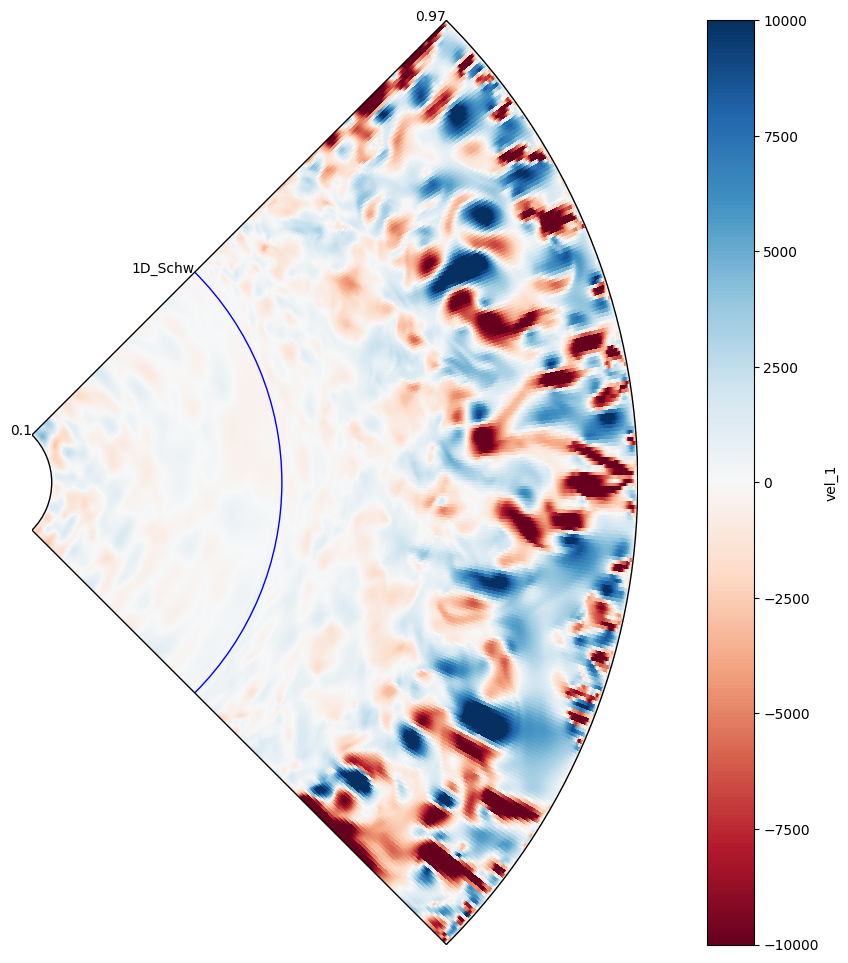

In [49]:
example_plot = cj_plotter.plot2D(t, r/r_tot, vel_1, -1e4, 1e4, cmap='RdBu') # , visible_ax=False)

example_plot.colorbar(label='vel_1')
example_plot.add_arc(r_env_init/r_tot, edgecolor='blue', label='1D_Schw')
example_plot.savefig('young_sun_vel_1.png')

## Vorticity

In [50]:
vorticity = np.genfromtxt('young_sun_2d_vorticity.csv',delimiter=',').T

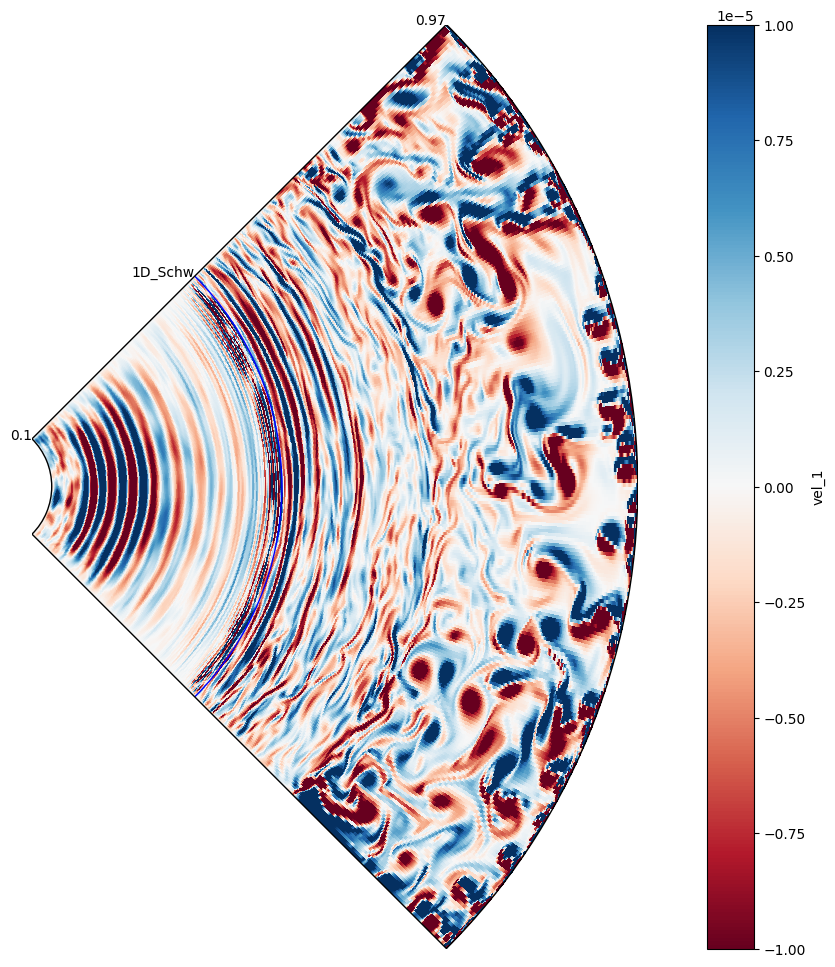

In [51]:
example_plot = cj_plotter.plot2D(t, r/r_tot, vorticity, -1e-5, 1e-5, cmap='RdBu') # , visible_ax=False)

example_plot.colorbar(label='vel_1')
example_plot.add_arc(r_env_init/r_tot, edgecolor='blue', label='1D_Schw')
example_plot.savefig('young_sun_vorticity.png')

## Temperature fluctuations

In [52]:
from music_scripts.derived_fields import temp

In [83]:
T = temp(sim[32400]).array()

In [84]:
T_r = np.mean(T, axis=1)
Temp_fluc = T - T_r[:, np.newaxis]

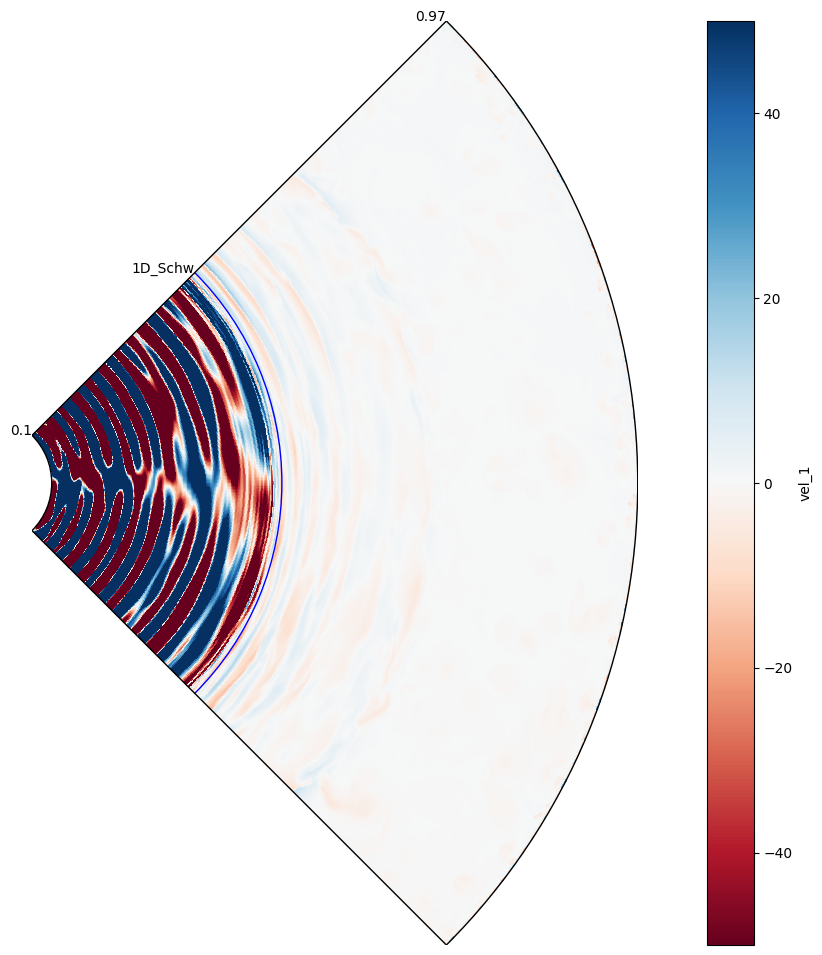

In [85]:
example_plot = cj_plotter.plot2D(t, r/r_tot, Temp_fluc, -50, 50, cmap='RdBu') # , visible_ax=False)

example_plot.colorbar(label='vel_1')
example_plot.add_arc(r_env_init/r_tot, edgecolor='blue', label='1D_Schw')

In [86]:
import matplotlib.pyplot as plt

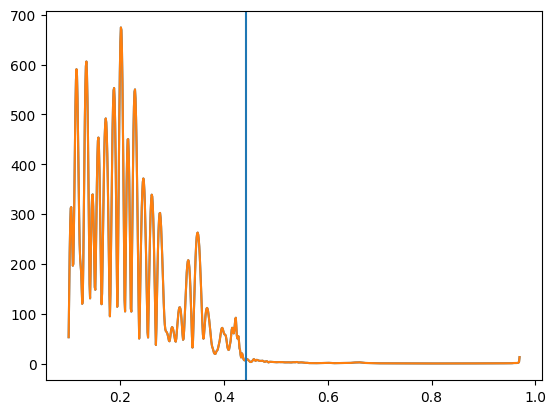

In [87]:
plt.plot(r/r_tot,np.sqrt(np.mean(Temp_fluc**2, axis=1)))
plt.plot(r/r_tot,np.std(T, axis=1, ddof=0))
# plt.plot(r/r_tot,T_r)
plt.axvline(r_env_init/r_tot)

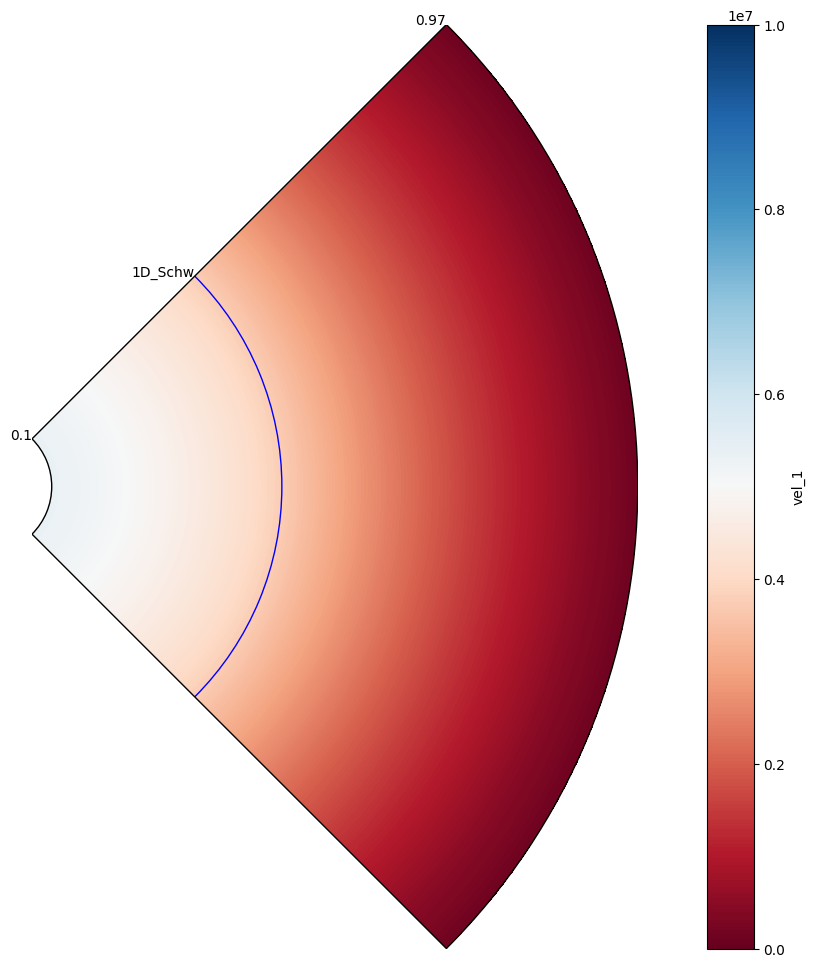

In [88]:
example_plot = cj_plotter.plot2D(t, r/r_tot, T, 0, 1e7, cmap='RdBu') # , visible_ax=False)

example_plot.colorbar(label='vel_1')
example_plot.add_arc(r_env_init/r_tot, edgecolor='blue', label='1D_Schw')